In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/quantbruce/real-estate-price-prediction/Real estate.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/quantbruce/real-estate-price-prediction/Real estate.csv")

In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
No,414.0,207.500000,119.655756,1.00000,104.250000,207.50000,310.750000,414.00000
X1 transaction date,414.0,2013.148971,0.281967,2012.66700,2012.917000,2013.16700,2013.417000,2013.58300
X2 house age,414.0,17.712560,11.392485,0.00000,9.025000,16.10000,28.150000,43.80000
X3 distance to the nearest MRT station,414.0,1083.885689,1262.109595,23.38284,289.324800,492.23130,1454.279000,6488.02100
X4 number of convenience stores,414.0,4.094203,2.945562,0.00000,1.000000,4.00000,6.000000,10.00000
X5 latitude,414.0,24.969030,0.012410,24.93207,24.963000,24.97110,24.977455,25.01459
X6 longitude,414.0,121.533361,0.015347,121.47353,121.528085,121.53863,121.543305,121.56627
Y house price of unit area,414.0,37.980193,13.606488,7.60000,27.700000,38.45000,46.600000,117.50000


In [7]:
df['X1 transaction date'] = pd.to_datetime(df['X1 transaction date'])


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns.tolist()

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area']

In [10]:
numeric = df.select_dtypes(include=np.number).columns
category = df.select_dtypes(exclude=np.number).columns.tolist()
print(numeric)

Index(['No', 'X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')


Text(0, 0.5, 'house price')

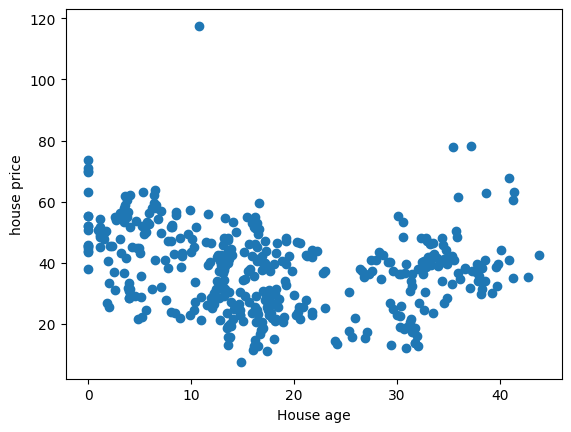

In [11]:
plt.scatter(df['X2 house age'], df['Y house price of unit area'])
plt.xlabel('House age')
plt.ylabel('house price')

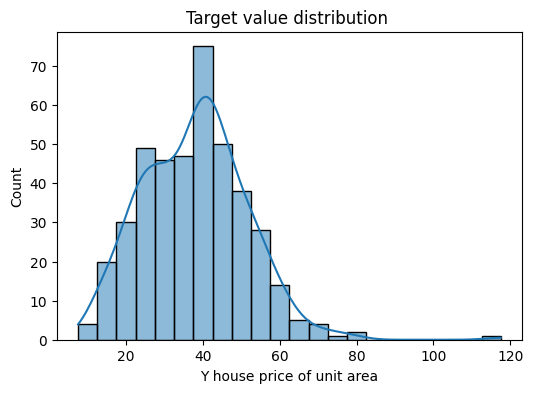

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Y house price of unit area'], kde = True)
plt.title('Target value distribution ')
plt.show()

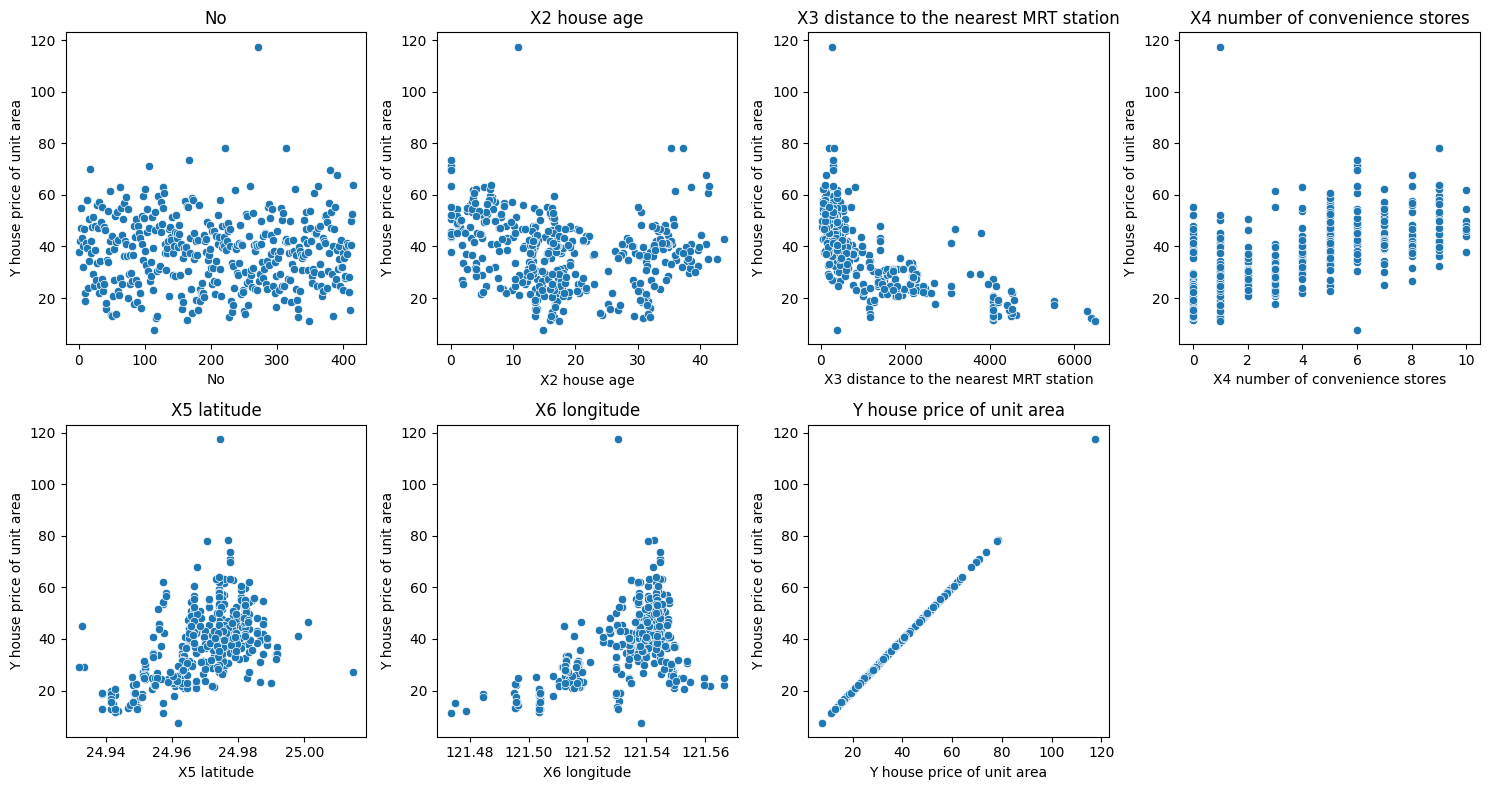

In [13]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numeric):
    plt.subplot(2,4,i+1)
    sns.scatterplot(x=df[col], y = df['Y house price of unit area'])
    plt.title(col)
plt.tight_layout()
plt.show()
#There are outliers in the dataset

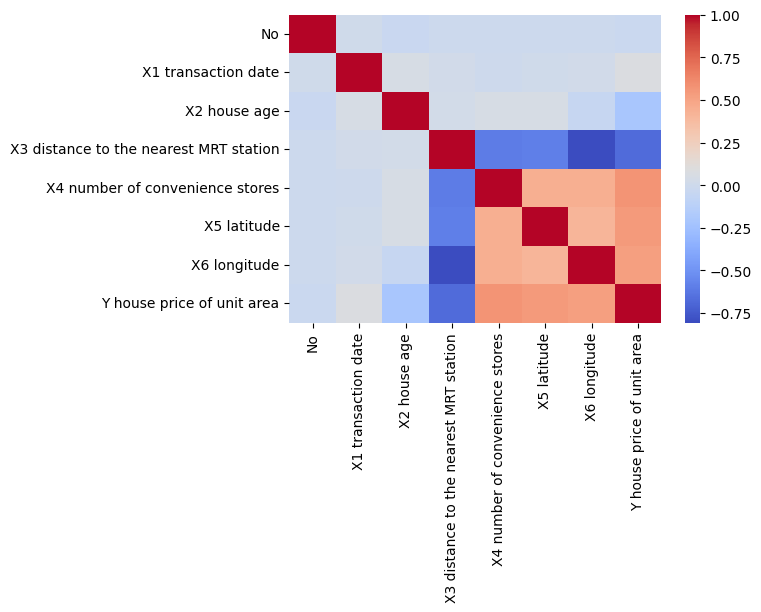

In [14]:
plt.figure(figsize = (6,4))
sns.heatmap(df.corr(),cmap = 'coolwarm')
plt.show()

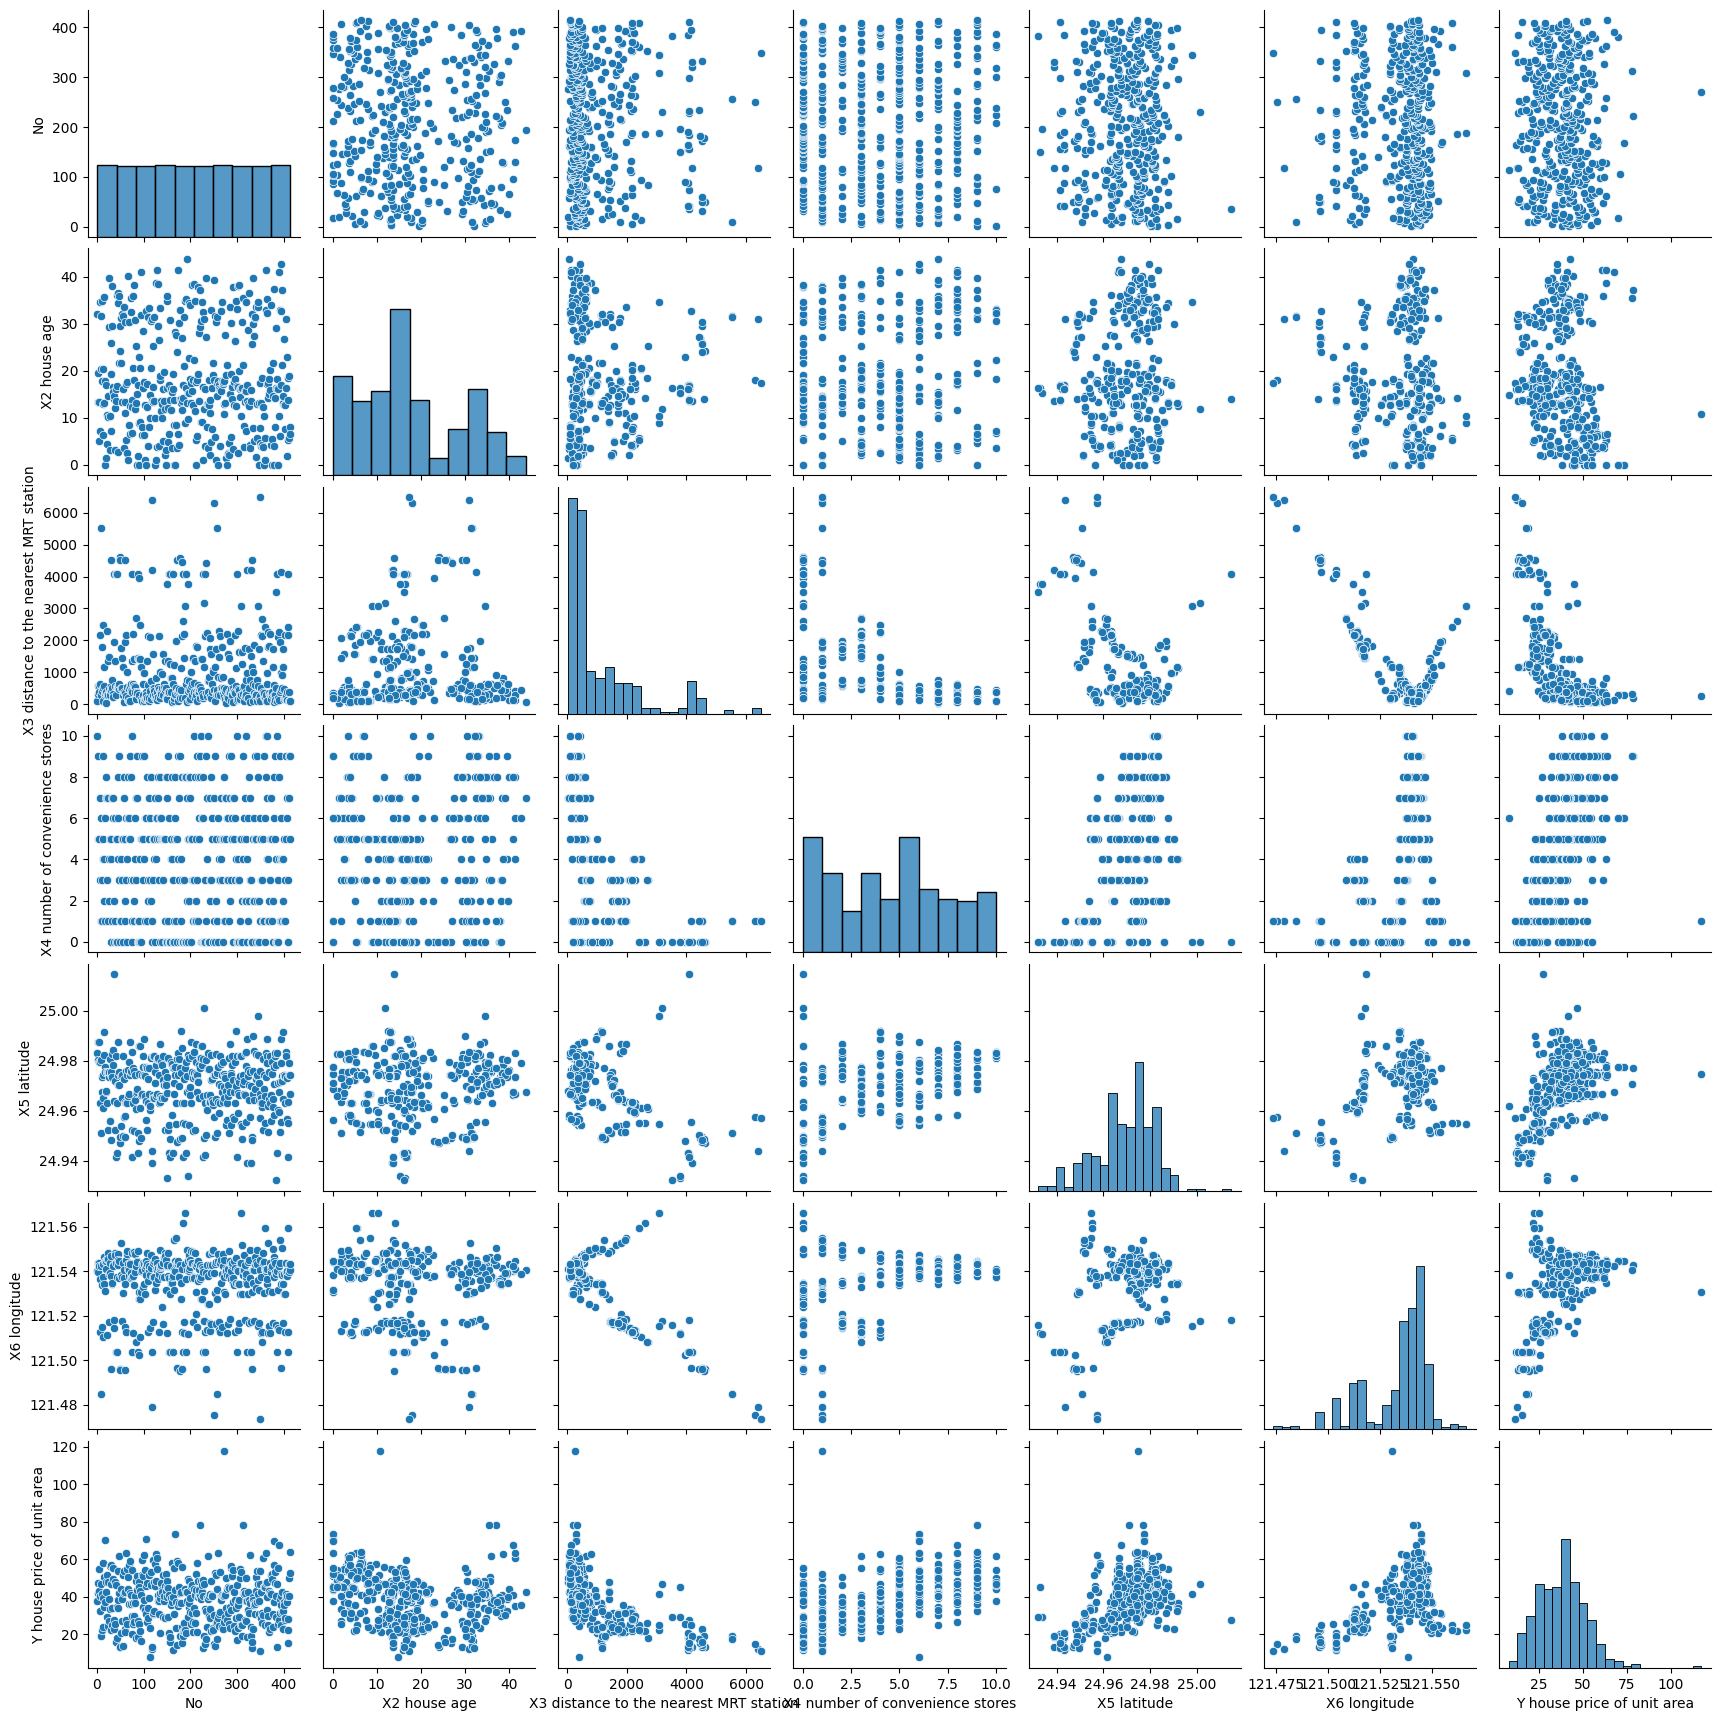

In [15]:
sns.pairplot(df)
plt.show()

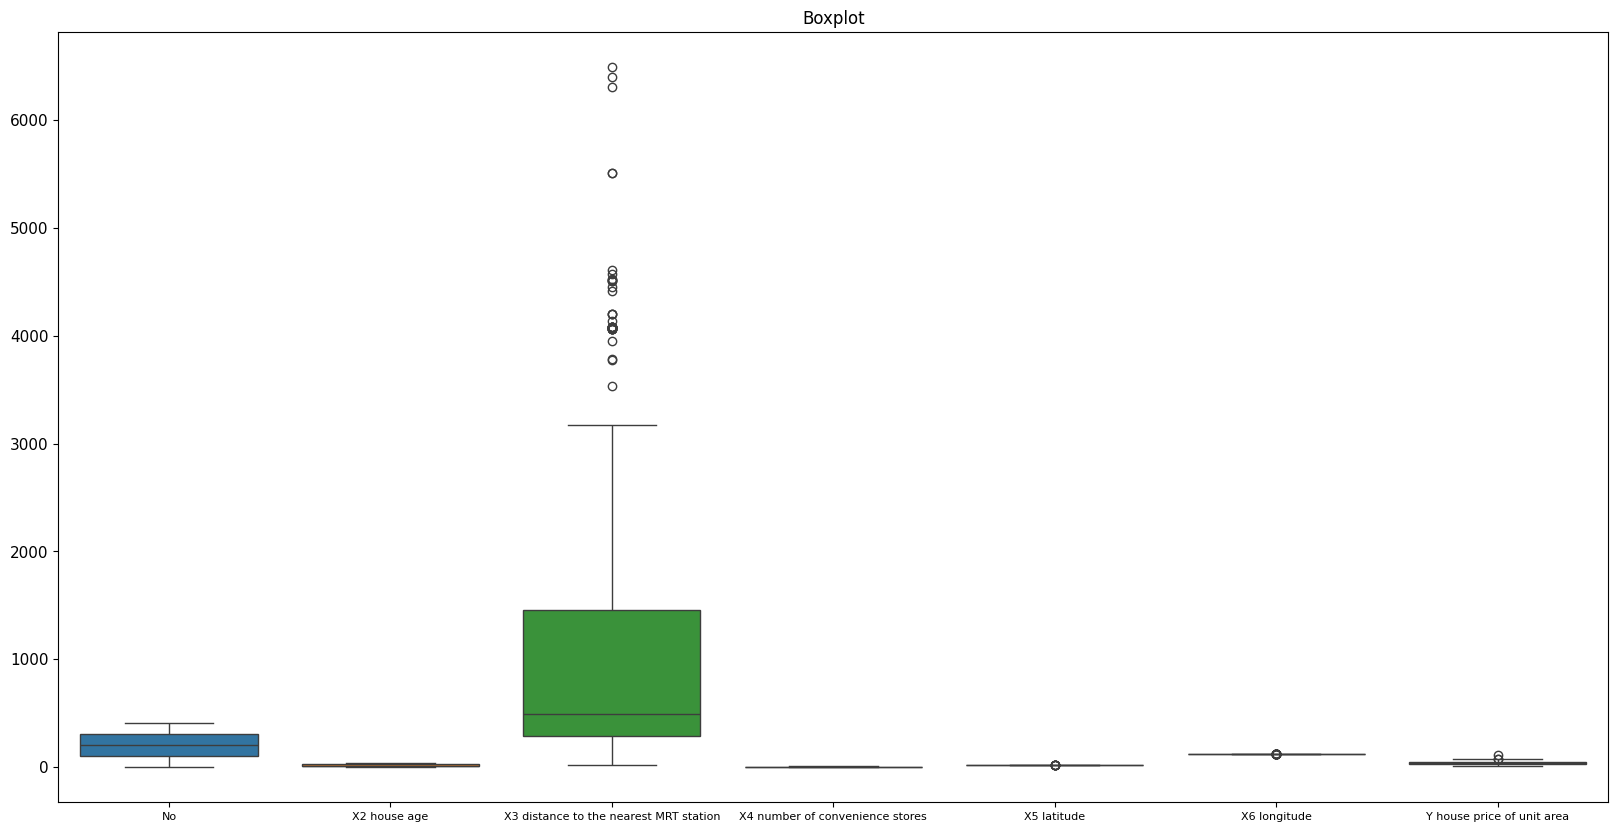

In [16]:
plt.figure(figsize=(20,10))
sns.boxplot(df)
plt.title('Boxplot')
plt.xticks(fontsize=8)
plt.yticks(fontsize = 11)
plt.show()

In [17]:
numeric_cols = df.select_dtypes(include='number').columns

df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Shape after cleaning:", df_clean.shape)
print("Max X3 after cleaning:", df_clean['X3 distance to the nearest MRT station'].max())

Shape after cleaning: (303, 8)
Max X3 after cleaning: 1962.628


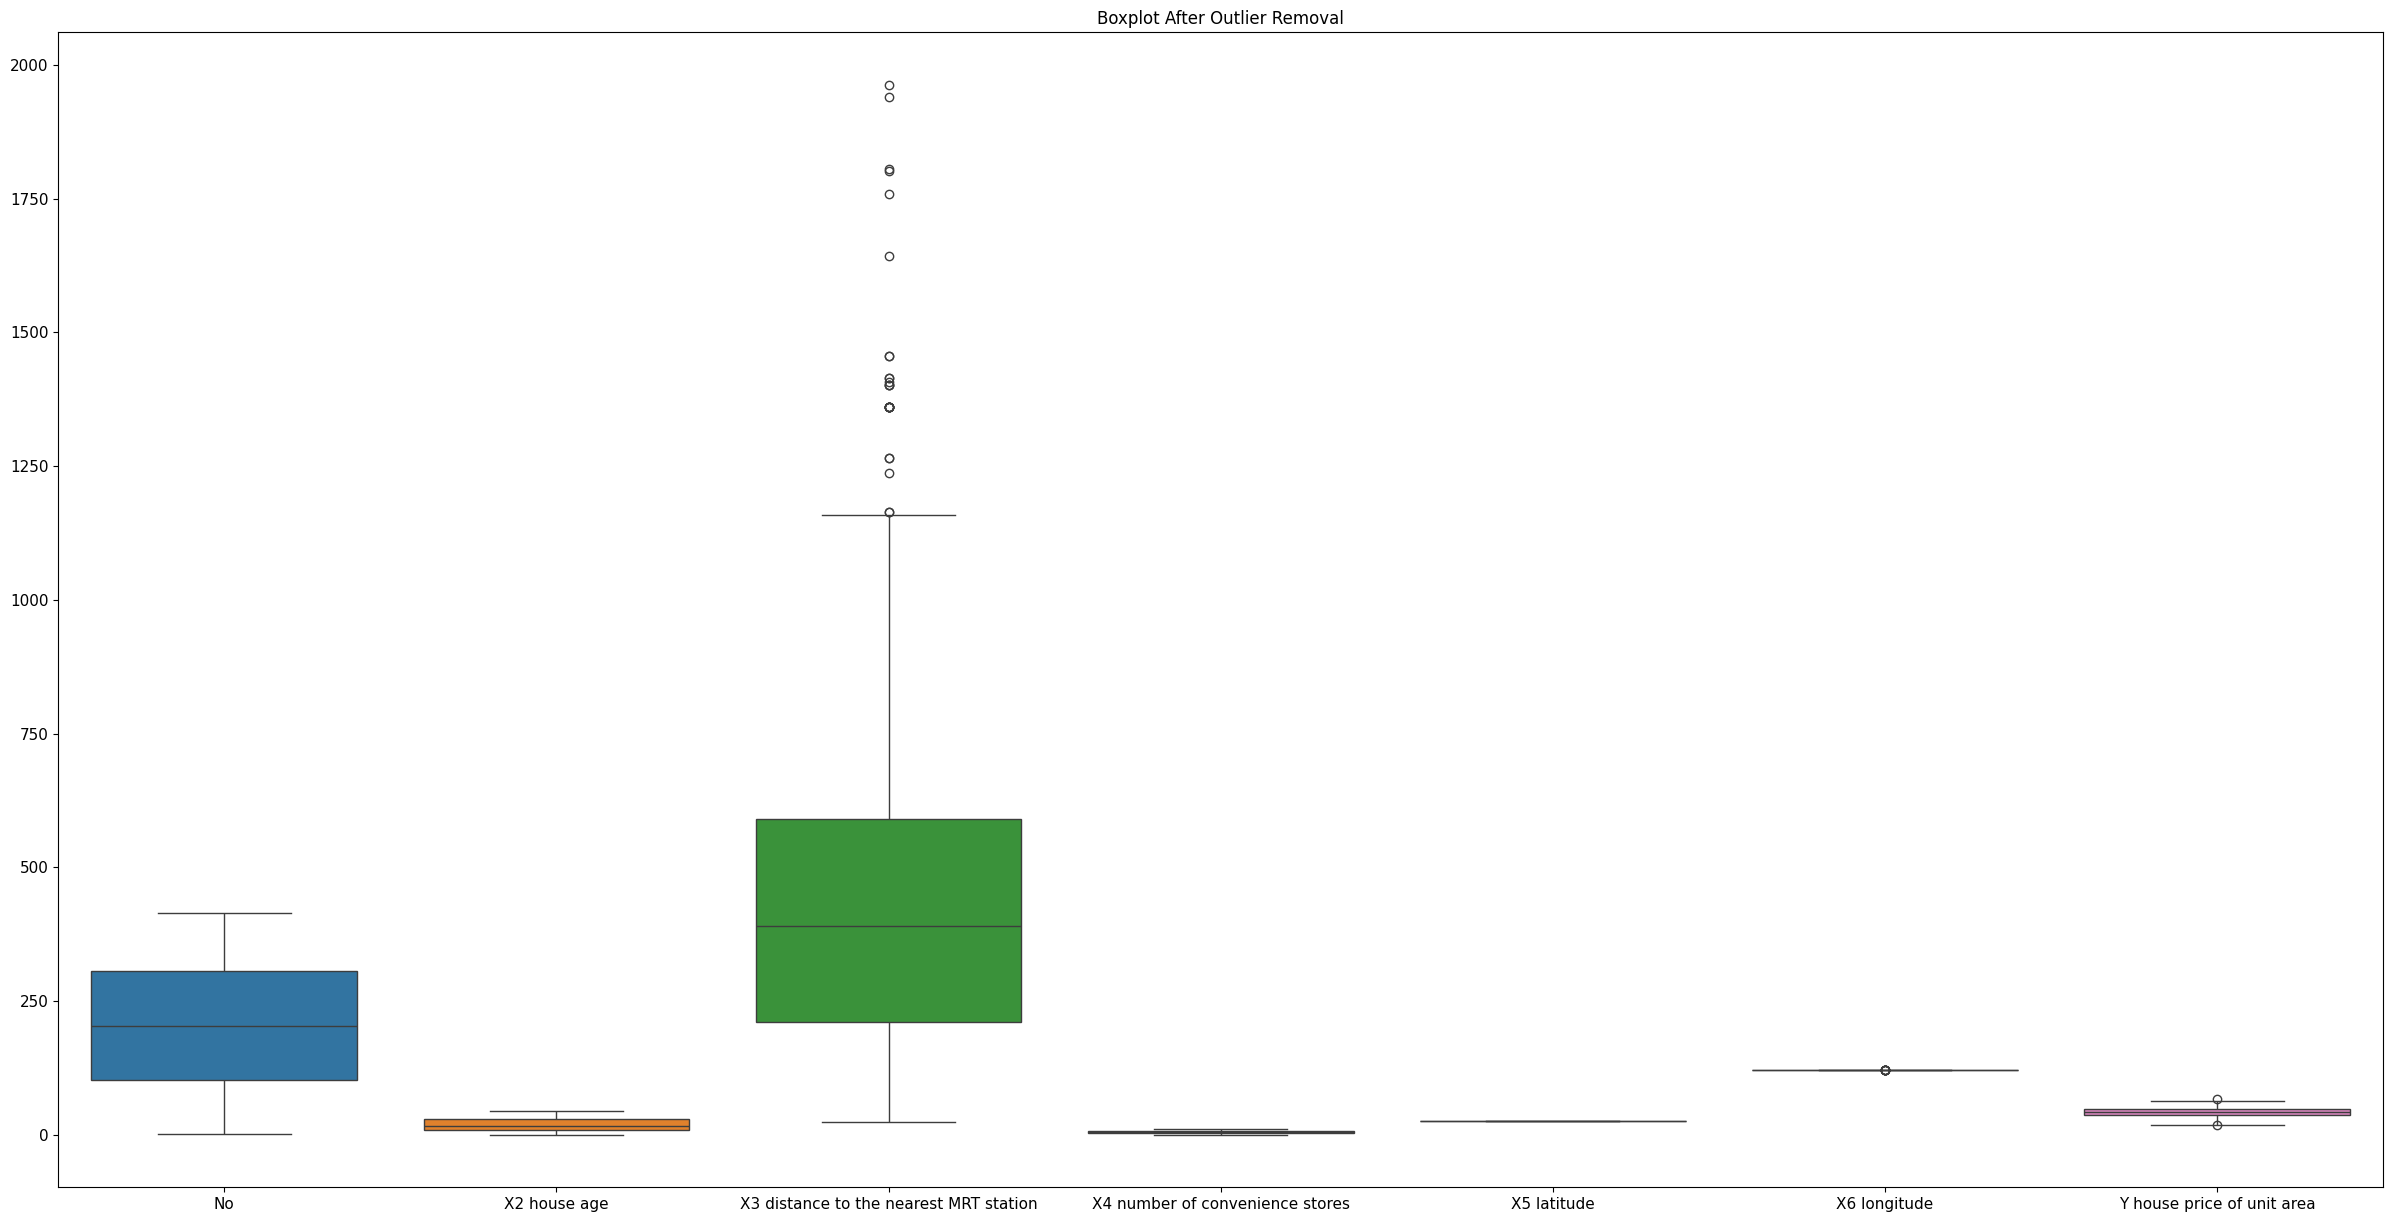

In [18]:
plt.figure(figsize=(30, 15))
sns.boxplot(data=df_clean)
plt.title("Boxplot After Outlier Removal")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

In [19]:
print(df_clean['X3 distance to the nearest MRT station'].describe())

count     303.000000
mean      494.017158
std       385.800521
min        23.382840
25%       209.918900
50%       390.568400
75%       589.408450
max      1962.628000
Name: X3 distance to the nearest MRT station, dtype: float64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
X = df.drop(['Y house price of unit area', 'No','X1 transaction date'], axis=1, errors='ignore')
y = df['Y house price of unit area']
X_test, X_train, y_test, y_train = train_test_split( X , y , test_size = 0.2, random_state  = 42)

In [22]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6.413544037142258
RMSE: 9.29229383802998
R2 Score: 0.5409299053218448


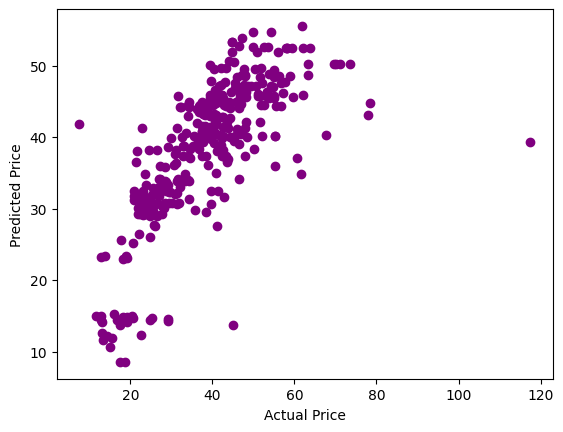

In [24]:
plt.scatter(y_test, y_pred, color = 'purple')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

